# Airline Passenger Growth & Seasonality Time-Series Analysis

| Attribute | Description | Data Type | Example Value |
| :--- | :--- | :--- | :--- |
| **Dataset Name** | Seaborn / R `flights` dataset | - | `flights` |
| **Source** | Monthly airline passenger numbers 1949–1960 (Box & Jenkins) | - | AirPassengers / Box & Jenkins (1976) |
| **Total Rows** | 144 observations (12 years × 12 months) | - | 144 |
| **Total Columns** | 3 | - | 3 |
| **Time Period** | January 1949 – December 1960 | Date / Time | 1949-01 to 1960-12 |
| **Frequency** | Monthly | Category | Monthly |

### Column Schema

| Column Name | Description | Data Type | Range / Domain | Sample Value |
| :--- | :--- | :--- | :--- | :--- |
| `year` | Year of observation | Integer / Categorical | 1949 – 1960 | `1949` |
| `month` | Month of observation | String / Categorical / Factor | Jan, Feb, Mar, ..., Dec | `Jan` |
| `passengers` | Total monthly international airline passengers (in thousands) | Integer | 104 – 622 | `112` |

---

### 1. Set-up and Data Inspection

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid') # set visual style

df_flights = sns.load_dataset('flights') # load built-in flights dataset

print("Dataset shape: ", df_flights.shape)
print("\nData Types & Info: ")
print(df_flights.info())

df_flights.head(12) # display a full 1-year cycle (month is in ascending by default in this dataset)

Dataset shape:  (144, 3)

Data Types & Info: 
<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   year        144 non-null    int64   
 1   month       144 non-null    category
 2   passengers  144 non-null    int64   
dtypes: category(1), int64(2)
memory usage: 2.9 KB
None


,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121
5,1949,Jun,135
6,1949,Jul,148
7,1949,Aug,148
8,1949,Sep,136
9,1949,Oct,119


### 2. Feature Engineering (Creating Datetime & Growth Metrics)
To analyze temporal trends effectively, we engineer two columns:
1. `year_month`/`date`: a combined datetime column (YYYY-MM-01) for continuous time-series plotting
2. `yoy_growth`: Year-over-Year percentage change compared to the exact same month in the previous year.

In [2]:
df_clean = df_flights.copy() # creating copy so that original won't be affected

# create a true datetime column for time-series axes
# 1. .astype(str): converts numerical years/months into text (strings); 2024 becomes '2024'
# 2. pd.to_datetime(...): converts combined text string into an actual pandas datetime64 data type
# using datetime64 data type gives pandas calendar intelligence
df_clean['date'] = pd.to_datetime(
    df_clean['year'].astype(str) + '-' + df_clean['month'].astype(str) + '-01'
) 

# sort chronologically as ['date'] is now of datatype datetime64
# 1. .sort_values('date'): reorders all rows first in chronological order based on 'date' column (oldest dates to newest)
# 2.a. .reset_index(): generates a brand new index (this is a new column; 0, 1, 2) because we did sorting. without this, index won't be chronological. 
# 2.b. drop=True: tells pandas to discard the old index instead of keeping it as a regular column (since reset_index() does the reordering of index)
df_clean = df_clean.sort_values('date').reset_index(drop=True) 

# calculate YoY growth per month (% change compared to 12 months prior)
df_clean['yoy_growth_pct'] = df_clean['passengers'].pct_change(12) * 100 # pct.change(12) is a built-in method in pandas; calculates fractional change

df_clean.head(15)

,year,month,passengers,date,yoy_growth_pct
0,1949,Jan,112,1949-01-01,NaN
1,1949,Feb,118,1949-02-01,NaN
2,1949,Mar,132,1949-03-01,NaN
3,1949,Apr,129,1949-04-01,NaN
4,1949,May,121,1949-05-01,NaN
5,1949,Jun,135,1949-06-01,NaN
6,1949,Jul,148,1949-07-01,NaN
7,1949,Aug,148,1949-08-01,NaN
8,1949,Sep,136,1949-09-01,NaN
9,1949,Oct,119,1949-10-01,NaN


### 3. Overall Long-Term Trend Plot 
Using `sns.lineplot`. We visualize the macro trajectory of air travel from 1949 to 1960.

Note: 
Macro trends are long-term, structural shifts in culture or markets, while micro trends are short-lived, rapid movements that capture immediate attention.

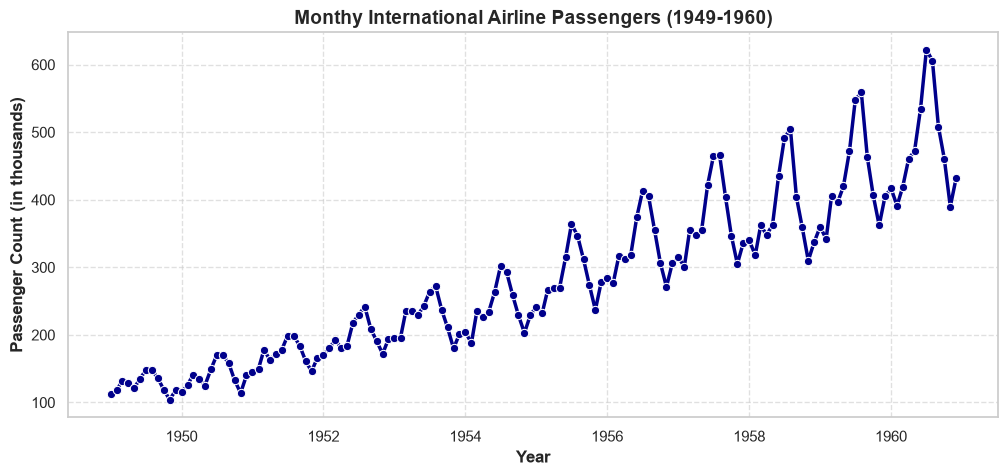

In [3]:
plt.figure(figsize=(12, 5)) # set-up canvas

# continuous time-series line plot
sns.lineplot(
    data=df_clean,
    x='date',
    y='passengers',
    color='darkblue',
    linewidth=2.5,
    marker='o'
)

plt.title('Monthy International Airline Passengers (1949-1960)', fontweight='bold', fontsize=14)
plt.xlabel('Year', fontweight='bold')
plt.ylabel('Passenger Count (in thousands)', fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6) # enable grid lines with linestyle of '--' and alpha = 0.6
plt.show()

### 4. Seasonality Analysis (Overlaying Yearly Curves)

Does travel surge during specific months every year? We overlay annual curves using `hue=year` to isolate seasonal rhythms.

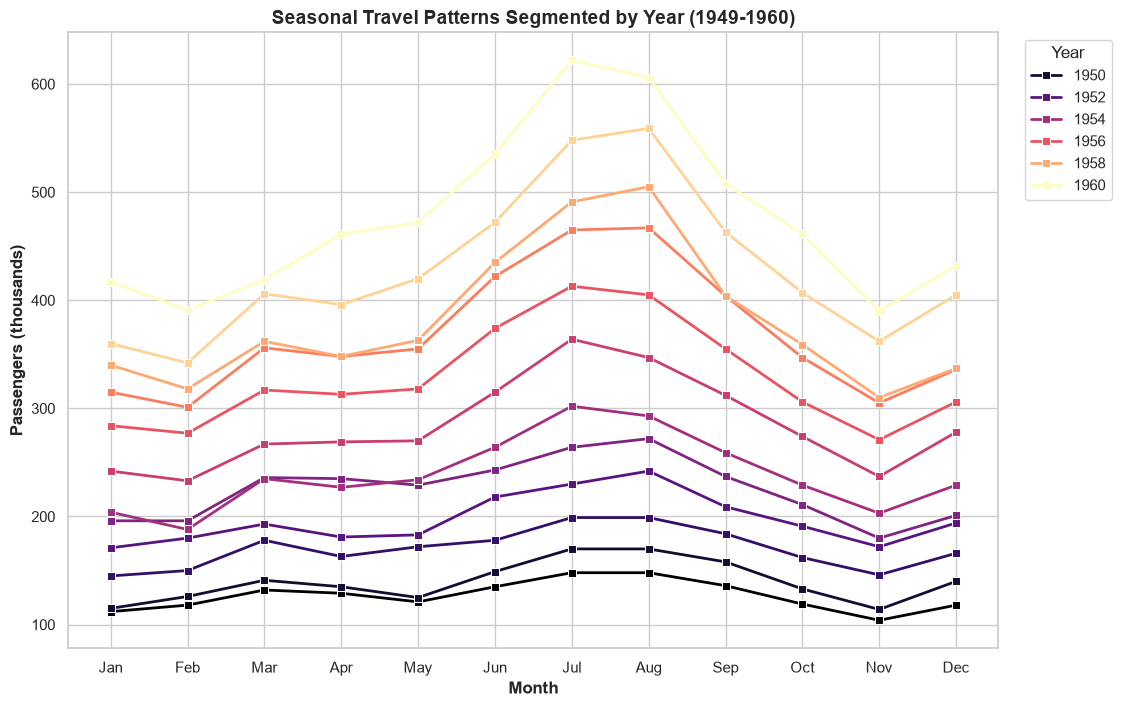

In [4]:
plt.figure(figsize=(12, 8)) # set canvas

# monthly trends color-coded by year
sns.lineplot(
    data=df_clean,
    x='month',
    y='passengers',
    hue='year',
    palette='magma',
    linewidth=2,
    marker='s'
)

plt.title('Seasonal Travel Patterns Segmented by Year (1949-1960)', fontweight='bold', fontsize=14)
plt.xlabel('Month', fontweight='bold')
plt.ylabel('Passengers (thousands)', fontweight='bold')
plt.legend(title='Year', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()

### 5. Data Reshaping (`.pivot()`)) & Seasonality Heatmap
To visualize every year and month simultaneously, we pivot the DataFrame into a 12 x 12 matrix and construct a Seaborn Heatmap.

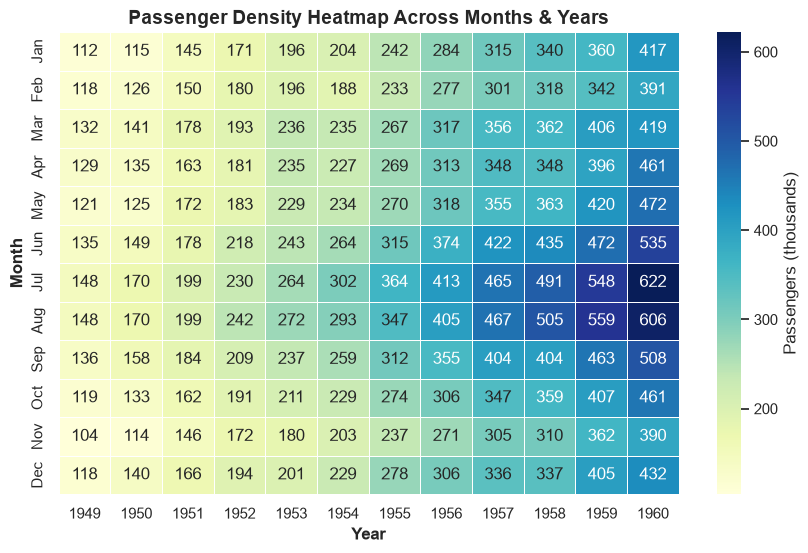

In [5]:
# pivot data: months on y-axis, years on x-axis
flights_pivot = df_clean.pivot(index='month', columns='year', values='passengers')
# index: rows (vertical axis down the table)
# columns: columns (horizontal axis down the table)

plt.figure(figsize=(10, 6)) # set canvas

sns.heatmap(
    flights_pivot,
    annot=True, # displays the value of each cell in the heatmap,
    fmt = 'd',
    cmap = 'YlGnBu',
    linewidth=0.5,
    cbar_kws={'label': 'Passengers (thousands)'}
)

plt.title('Passenger Density Heatmap Across Months & Years', fontweight='bold', fontsize=14)
plt.xlabel('Year', fontweight='bold')
plt.ylabel('Month', fontweight='bold')
plt.show()


### 6. Rolling Averages (Smoothing Seasonal Volatility)
To observe the underlying macro trend without seasonal spikes, we calculate a 12-Month Moving Average.

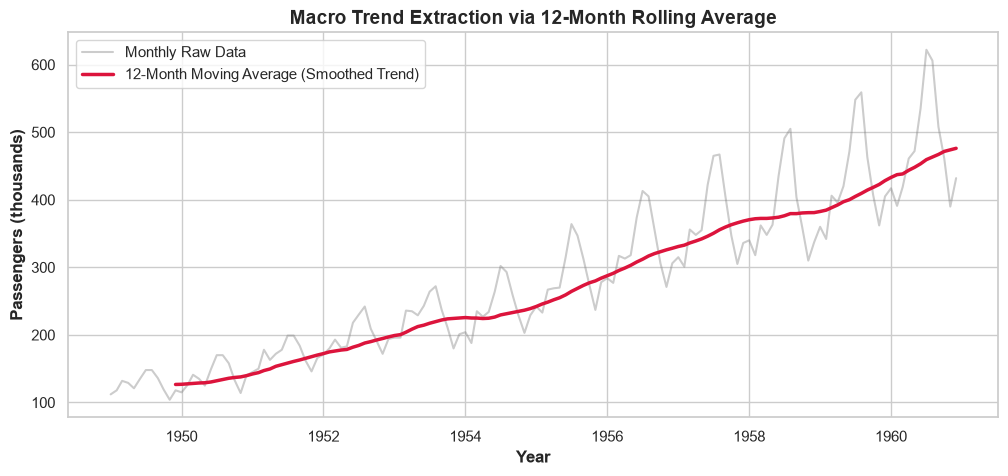

In [6]:
# calculate 12-month rolling mean
df_clean['rolling_mean_12m'] = df_clean['passengers'].rolling(window=12).mean() # what does this mean?

plt.figure(figsize=(12, 5))

# plot raw monthly data alongside 12-month moving average
# plt.plot(): function used to draw 2D line plots (or marker plots) by connecting a series of (x,y) coordinates
    # syntax: (x-axis, y-axis, label, alpha, color)
# NOTE: can use the sns.lineplot here^

# plotting the raw monthly data: 
plt.plot(df_clean['date'], df_clean['passengers'], label='Monthly Raw Data', alpha=0.4, color='gray')

# plotting the 12-month moving average
plt.plot(df_clean['date'], df_clean['rolling_mean_12m'], label='12-Month Moving Average (Smoothed Trend)', color='crimson', linewidth=2.5)


plt.title('Macro Trend Extraction via 12-Month Rolling Average', fontweight='bold', fontsize=14)
plt.xlabel('Year', fontweight='bold')
plt.ylabel('Passengers (thousands)', fontweight='bold')
plt.legend()
plt.show()

#### Why plot the rolling averages?
While a standard line plot shows every raw data point, real-world time series data is often messy, noisy, or heavily influenced by recurring short-term cycles (like weekends or daily spikes).

Plotting a rolling average (or moving average) acts as a smoothing filter. It calculates the mean of a fixed window of consecutive data points (e.g, 7-day, 30-day) and moves that window step-by-step through time.

Key reasons are:
1. Denoising and trend identification. It smooths out random noise so the true underlying trend (upward, downward, or flat) becomes immediately visible. Unlike the raw line plot, it shows high variance and spikes.
2. Eliminating seasonality (e.g., weekend drops). A standard daily plot shows a continuoys wave of peaks and troughs (lowest points in a series of data points) every 7 days. A 7-day rolling average averages out Monday-Sunday into a single point, effectivey neutralizing the day-of-week effect. This let's you see month-over-month shifts without weekend distortions.
3. Detect regime shifts and crossovers. It helps highlight momentum shifts such as short-term moving average (reacts quickly to recent events) and long-term moving average (represents the broader baseline).
4. Highlighting true anomalies. Spikes that stay close to the rolling average are usually expected fluctutations. Spikes that shoot far away from the rollling average stand out as clear outliers or anomalies that warrant investigation.

In short:
- raw line plot: "What exact value occured on day X?"; captures precise, raw data points at every timestamp
- rolling average: "Where is the overall trajectory heading over time?"; filters out short-term noise and recurring seasonal cycles

---
### Findings

#### 1. Macro Trend (Strong Positive Growth)
* **Consistent Expansion:** International air travel experienced steady, exponential-like growth from 1949 (~112k passengers/month) through 1960 (~606k passengers/month at peak).
* **12-Month Moving Average:** Filtering out seasonal noise confirms an uninterrupted upward trajectory across the entire 11-year observation window.



#### 2. Seasonality Rhythms (Summer Travel Spikes)
* **Peak Months:** Passenger volume consistently peaks during **July and August** across every single year, driven by summer vacations.
* **Trough Months:** **November and February** consistently represent the lowest travel demand periods of the year.
  

#### 3. Increasing Seasonal Amplitude
* **Multiplicative Seasonality:** The variance between peak (summer) and trough (winter) months widened as total overall passengers grew. The seasonal swing in 1960 (~200k difference) was drastically larger than in 1949 (~30k difference).